In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set(style="whitegrid")

In [27]:
# Load Data
train_trans = pd.read_csv("../data/raw/DataSet/train_transaction.csv")
train_id = pd.read_csv("../data/raw/DataSet/train_identity.csv")

# merge dataset
df = train_trans.merge(train_id, on="TransactionID", how="left")

print("Data Loaded Successfully!")

Data Loaded Successfully!


In [28]:
print("Shape:", df.shape)
display(df.head())

Shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [29]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB


In [30]:
print(df['isFraud'].value_counts())
print(df['isFraud'].value_counts(normalize=True))

isFraud
0    569877
1     20663
Name: count, dtype: int64
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


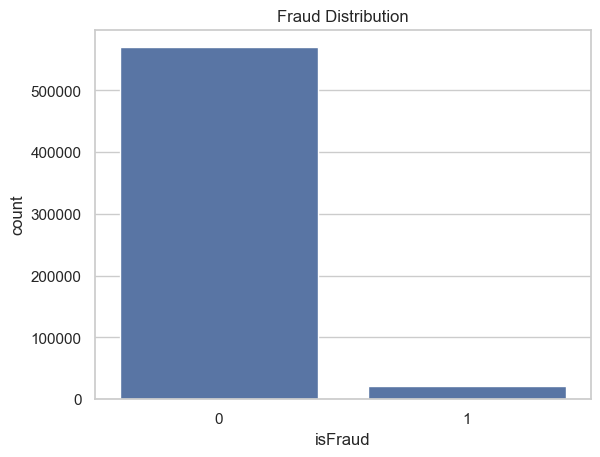

In [31]:
sns.countplot(x='isFraud', data=df)
plt.title("Fraud Distribution")
plt.show()

In [32]:
missing_percent = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'missing_percent': missing_percent
}).sort_values(by='missing_percent', ascending=False)

display(missing_df.head(20))

,missing_percent
id_24,99.196159
id_25,99.130965
id_07,99.127070
id_08,99.127070
id_21,99.126393
id_26,99.125715
id_27,99.124699
id_23,99.124699
id_22,99.124699
dist2,93.628374


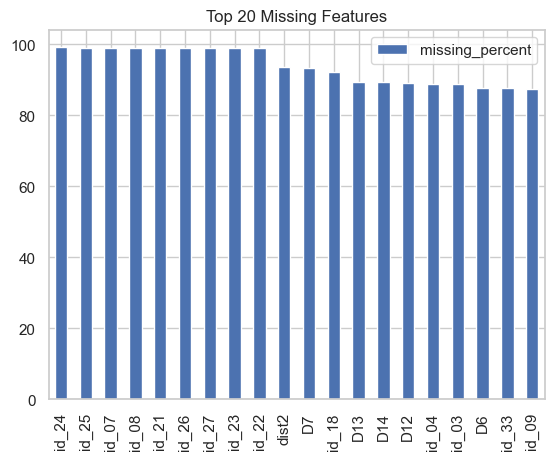

In [33]:
missing_df.head(20).plot(kind='bar')
plt.title("Top 20 Missing Features")
plt.show()

In [34]:
cols_to_drop = missing_percent[missing_percent > 90].index
df.drop(columns=cols_to_drop, inplace=True)

print("Remaining Shape:", df.shape)

Remaining Shape: (590540, 422)


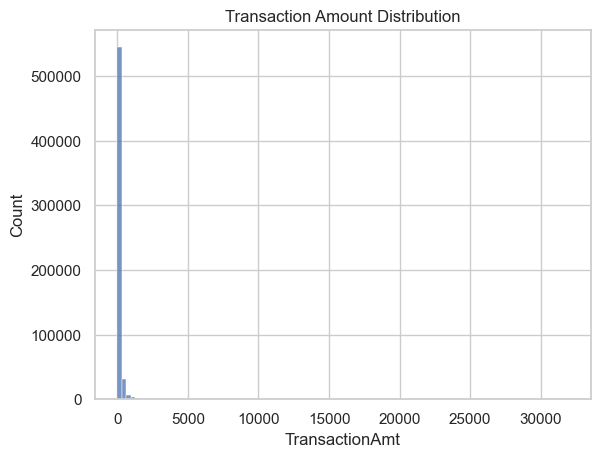

In [35]:
sns.histplot(df['TransactionAmt'], bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

C:\Users\Khaled\AppData\Local\Temp\ipykernel_21088\344969577.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])


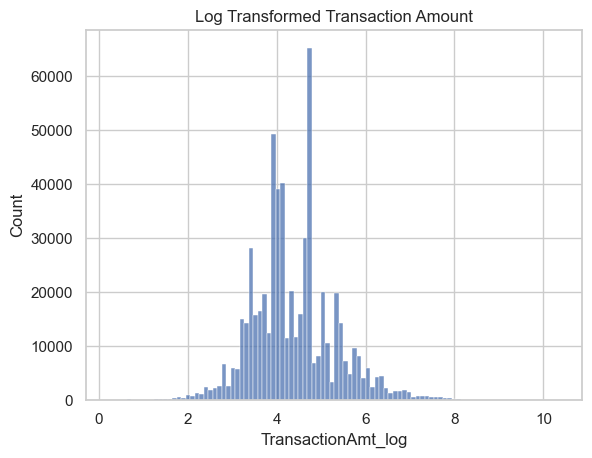

In [36]:
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
df = df.copy()
sns.histplot(df['TransactionAmt_log'], bins=100)
plt.title("Log Transformed Transaction Amount")

plt.show()

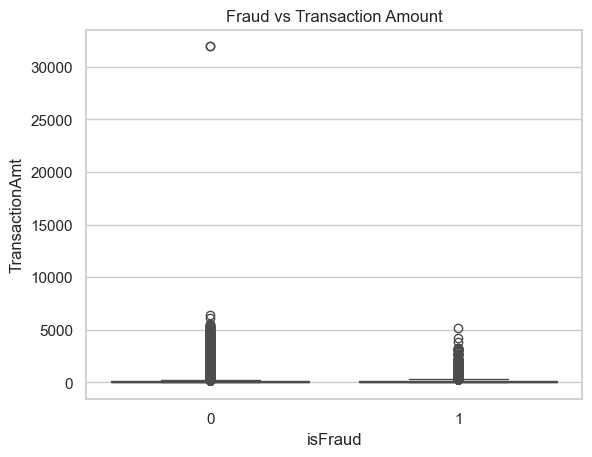

In [37]:
sns.boxplot(x='isFraud', y='TransactionAmt', data=df)
plt.title("Fraud vs Transaction Amount")
plt.show()

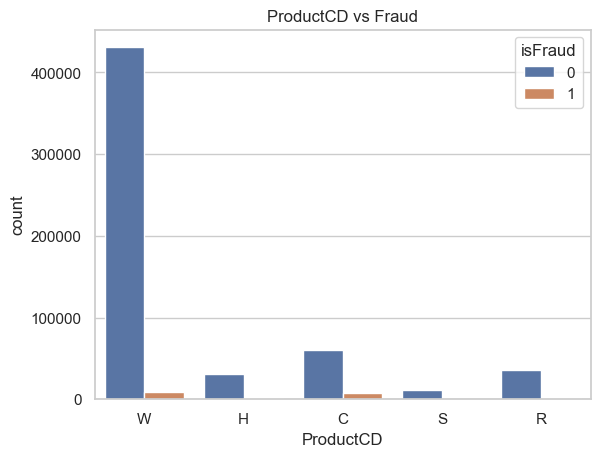

In [38]:
sns.countplot(x='ProductCD', hue='isFraud', data=df)
plt.title("ProductCD vs Fraud")
plt.show()

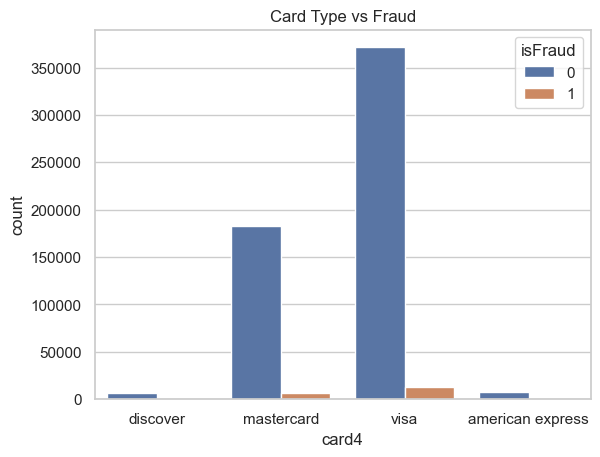

In [39]:
sns.countplot(x='card4', hue='isFraud', data=df)
plt.title("Card Type vs Fraud")
plt.show()

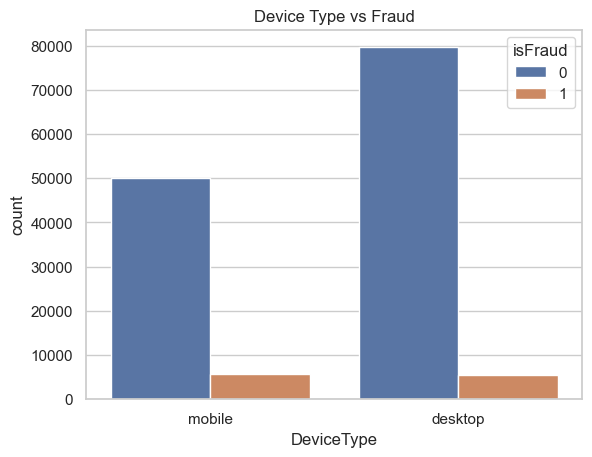

In [40]:
sns.countplot(x='DeviceType', hue='isFraud', data=df)
plt.title("Device Type vs Fraud")
plt.show()

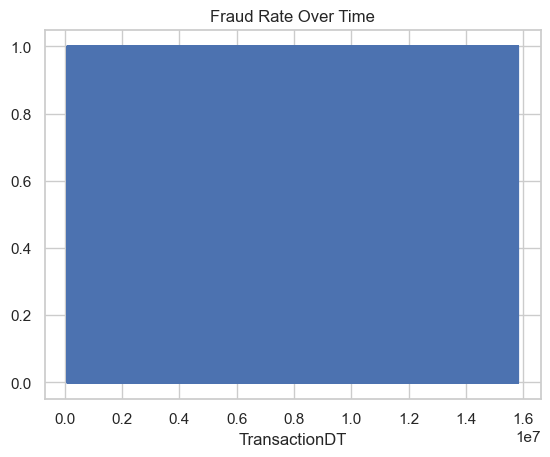

In [41]:
df.groupby('TransactionDT')['isFraud'].mean().plot()
plt.title("Fraud Rate Over Time")
plt.show()

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
Name: isFraud, dtype: float64

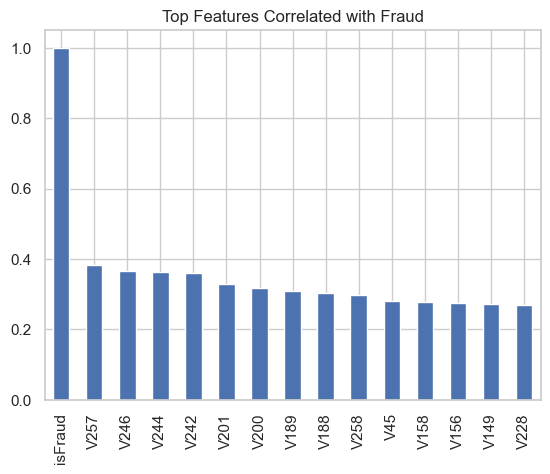

In [42]:
# Correlation
corr_target = df.corr(numeric_only=True)['isFraud'].sort_values(ascending=False)
# top 15
display(corr_target.head(15))

corr_target.head(15).plot(kind='bar')
plt.title("Top Features Correlated with Fraud")
plt.show()

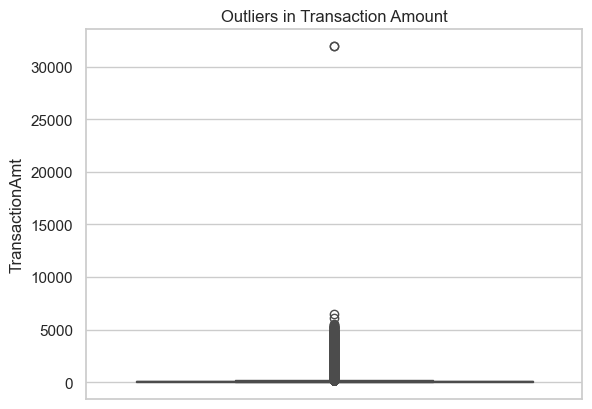

In [43]:
sns.boxplot(df['TransactionAmt'])
plt.title("Outliers in Transaction Amount")
plt.show()

In [44]:
df['TransactionAmt_decimal'] = (
    (df['TransactionAmt'] - df['TransactionAmt'].astype(int)) * 1000
)

display(df[['TransactionAmt','TransactionAmt_decimal']].head())

,TransactionAmt,TransactionAmt_decimal
0,68.5,500.0
1,29.0,0.0
2,59.0,0.0
3,50.0,0.0
4,50.0,0.0


In [45]:
print("Final Shape:", df.shape)

Final Shape: (590540, 424)
